# Student Info
## Name: Jia Changyu
## English Name: Iris
## ID: C00292876

# 1. Introduction

In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.metrics import confusion_matrix
import seaborn as sns
from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import warnings
warnings.filterwarnings('ignore')
import os

In [2]:
train_path = "../data/fashion-mnist_train.csv"
test_path = "../data/fashion-mnist_test.csv"

mnist_train = pd.read_csv(train_path)
mnist_test = pd.read_csv(test_path)

# 2. Initial Exploration

In [3]:
X_train = mnist_train.iloc[:, 1:].values
y_train = mnist_train.iloc[:, 0].values
X_test = mnist_test.iloc[:, 1:].values
y_test = mnist_test.iloc[:, 0].values

# Normalization: Scaling pixel values from 0-255 to 0-1.
X_train_normalized = X_train / 255.0
X_test_normalized = X_test / 255.0

print(f"\nThe range of pixel values in the normalized training set: [{X_train_normalized.min():.3f}, {X_train_normalized.max():.3f}]")


The range of pixel values in the normalized training set: [0.000, 1.000]


In [4]:
class SimplePerceptron:
    def __init__(self, input_size, output_size):
        # Initialize the weight matrix with a shape of (input_size, output_size).
        self.weights = np.random.randn(input_size, output_size) * 0.01
        self.bias = np.zeros((1, output_size))
    
    def forward(self, x):
        z = np.dot(x, self.weights) + self.bias
        # Activation Functions
        exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))
        return exp_z / np.sum(exp_z, axis=1, keepdims=True)
    
    def predict(self, x):
        probabilities = self.forward(x)
        return np.argmax(probabilities, axis=1)

# Initialize the network: 784 inputs, 10 outputs
input_size = 784
output_size = 10
simple_model = SimplePerceptron(input_size, output_size)

sample_input = X_train_normalized[:5]
predictions = simple_model.forward(sample_input)
print("\nThe predicted probability distribution of the first 5 images (each row sums up to 1):")
print(predictions)
print("\nThe predicted category is:", simple_model.predict(sample_input))
print("The actual label is:", y_train[:5])


The predicted probability distribution of the first 5 images (each row sums up to 1):
[[0.09756486 0.06804704 0.08948885 0.09558427 0.09443586 0.12223931
  0.0925658  0.13601622 0.10726091 0.09679688]
 [0.09511823 0.09180842 0.09567946 0.10439024 0.09448207 0.10462511
  0.09368843 0.12349917 0.09940305 0.09730581]
 [0.10889516 0.06697786 0.08563336 0.10129649 0.09310627 0.09628131
  0.09711143 0.13897021 0.12386638 0.08786154]
 [0.09559843 0.07931599 0.08909886 0.09553316 0.09411288 0.11658549
  0.09194547 0.12319351 0.12140822 0.09320798]
 [0.09716766 0.07275652 0.09939717 0.08569466 0.09665465 0.12603697
  0.09295415 0.11468918 0.12730878 0.08734026]]

The predicted category is: [7 7 7 7 8]
The actual label is: [2 9 6 0 3]



Data augmentation examples (enhanced versions of the first 5 images)：


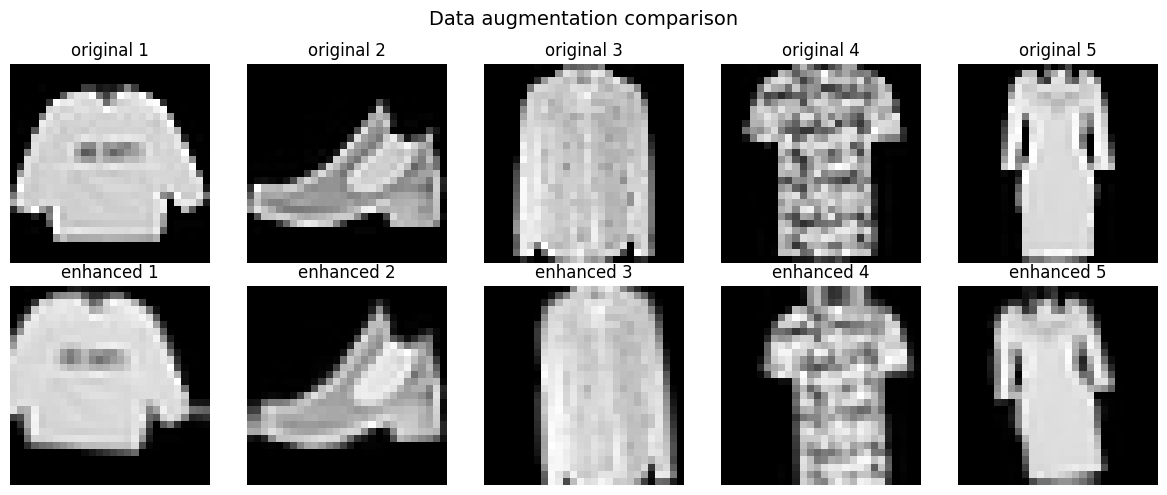

In [5]:
X_train_images = X_train_normalized.reshape(-1, 28, 28, 1)

# Create a data augmenter (with minor rotation, translation, and scaling)
datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
)

print("\nData augmentation examples (enhanced versions of the first 5 images)：")
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i in range(5):
    original_img = X_train_images[i].reshape(28, 28)
    augmented_img = datagen.random_transform(X_train_images[i]).reshape(28, 28)
    
    axes[0, i].imshow(original_img, cmap='gray')
    axes[0, i].set_title(f"original {i+1}")
    axes[0, i].axis('off')
    
    axes[1, i].imshow(augmented_img, cmap='gray')
    axes[1, i].set_title(f"enhanced {i+1}")
    axes[1, i].axis('off')
plt.suptitle("Data augmentation comparison", fontsize=14)
plt.tight_layout()
plt.show()

In [6]:
# Building Multi-Layer Neural Network with Keras
model = keras.Sequential([
    # Input Layer: Input 784 one-dimensional pixel points into the network
    keras.layers.Input(shape=(784,)),
    
    # The first hidden layer: 128 neurons, using the ReLU activation function
    keras.layers.Dense(128, activation='relu', name='hidden_layer_1'),
    
    # Dropout Layer: Preventing Overfitting
    keras.layers.Dropout(0.2, name='dropout_1'),
    
    # The second hidden layer: 64 neurons, using the ReLU activation function
    keras.layers.Dense(64, activation='relu', name='hidden_layer_2'),
    
    # Dropout Layer
    keras.layers.Dropout(0.2, name='dropout_2'),
    
    # Output layer: 10 neurons, using the Softmax activation function to obtain the probability of each class
    keras.layers.Dense(10, activation='softmax', name='output_layer')
])
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("\nSummary of Model Structure:")
model.summary()


Summary of Model Structure:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_layer_1 (Dense)          │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_layer_2 (Dense)          │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

The neural network model structure for dataset construction consists of two fully connected layers and Dropout regularization, with a total of approximately 109K parameters. The purpose is to verify and confirm that it is suitable for subsequent image classification training.

In [7]:
# Training and Evaluation of Models
epochs = 10
batch_size = 32
validation_split = 0.2

print(f"\nStart training...")
print(f"Training parameters: epochs={epochs}, batch_size={batch_size}, validation_split={validation_split}")

history = model.fit(
    X_train_normalized, 
    y_train,
    epochs=epochs,
    batch_size=batch_size,
    validation_split=validation_split,
    verbose=1
)

print("\nEvaluating the model on the test set...")
test_loss, test_acc = model.evaluate(X_test_normalized, y_test, verbose=0)
print(f"Test set loss: {test_loss:.4f}")
print(f"Accuracy of the test set: {test_acc:.4f}")


Start training...
Training parameters: epochs=10, batch_size=32, validation_split=0.2
Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7848 - loss: 0.6086 - val_accuracy: 0.8392 - val_loss: 0.4405
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8402 - loss: 0.4435 - val_accuracy: 0.8619 - val_loss: 0.3836
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8530 - loss: 0.4036 - val_accuracy: 0.8635 - val_loss: 0.3842
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8593 - loss: 0.3876 - val_accuracy: 0.8661 - val_loss: 0.3646
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8664 - loss: 0.3664 - val_accuracy: 0.8794 - val_loss: 0.3455
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8687 - loss: 0.3525 - val_accuracy: 0.8792 - val_loss: 0.3474
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8745 - loss: 0.3422 - val_accuracy: 0.8823 - val_loss: 0.3392
Epo

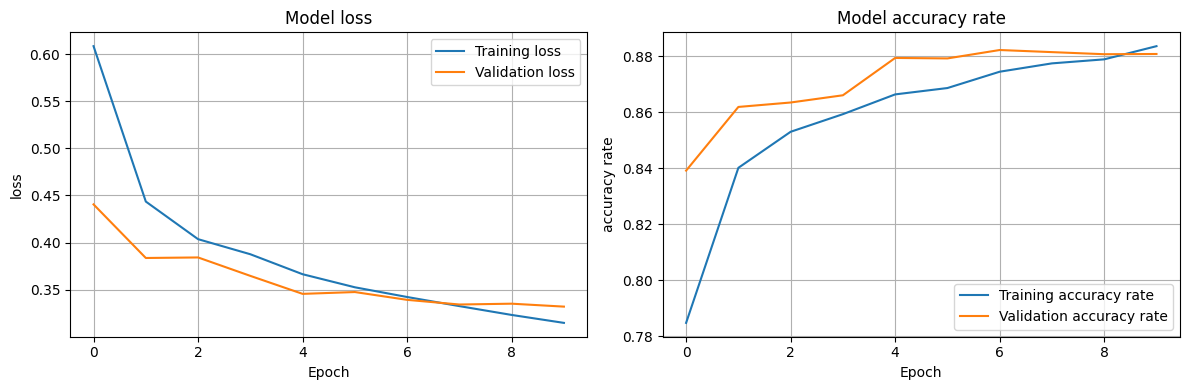

In [8]:
# Visualization of Training Process
def plot_training_history(history):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    
    # Draw the loss curve
    ax1.plot(history.history['loss'], label='Training loss')
    ax1.plot(history.history['val_loss'], label='Validation loss')
    ax1.set_title('Model loss')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('loss')
    ax1.legend()
    ax1.grid(True)
    
    # Draw the accuracy curve
    ax2.plot(history.history['accuracy'], label='Training accuracy rate')
    ax2.plot(history.history['val_accuracy'], label='Validation accuracy rate')
    ax2.set_title('Model accuracy rate')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('accuracy rate')
    ax2.legend()
    ax2.grid(True)
    
    plt.tight_layout()
    plt.show()

plot_training_history(history)

The curves of loss and accuracy during training and validation both improved rapidly and then stabilized, showing that the model effectively converged and there was no overfitting.

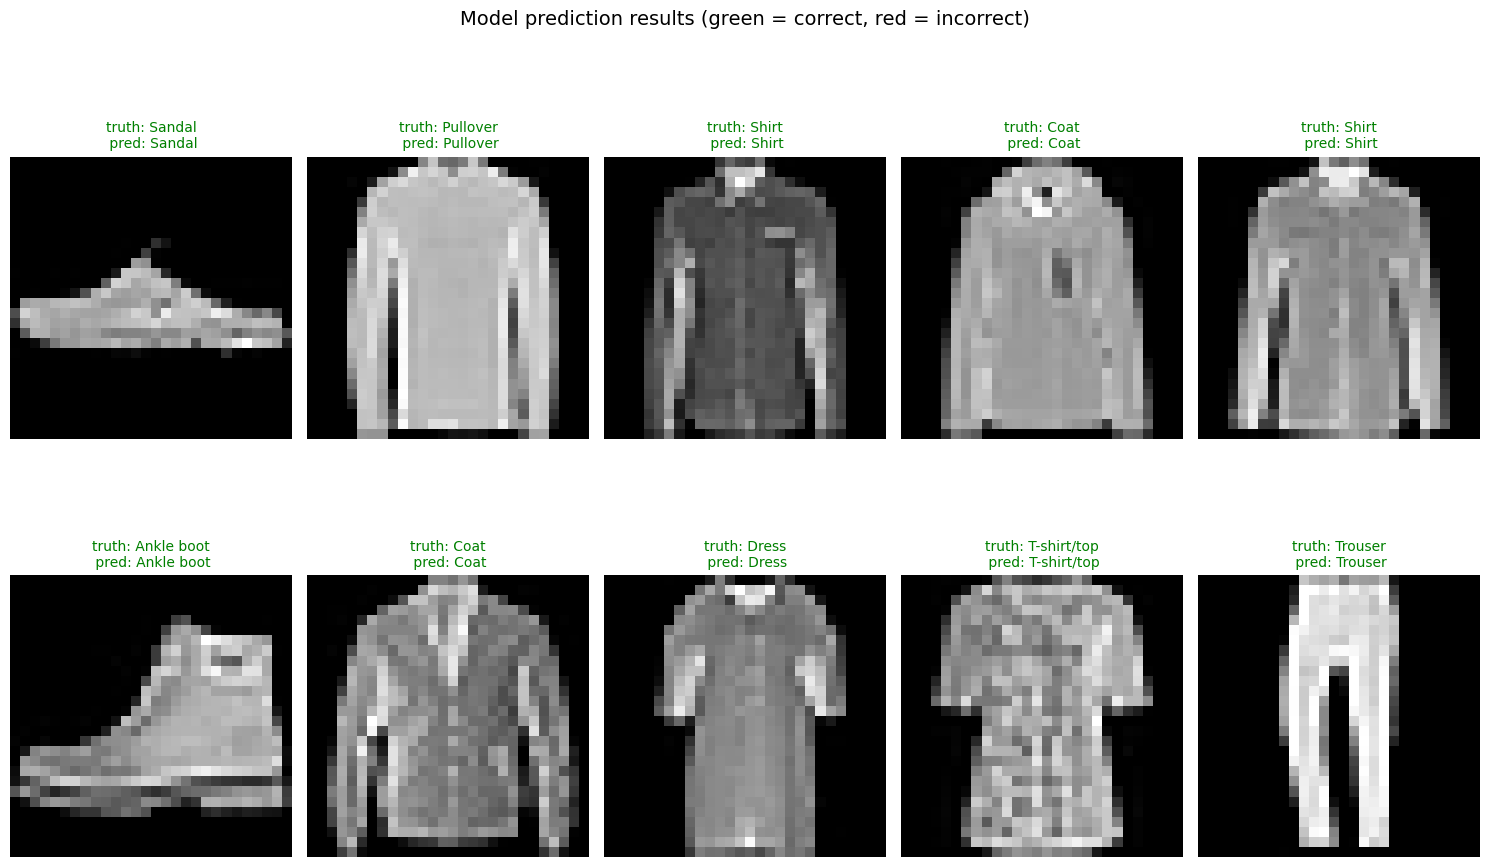

In [9]:
# Prediction
num_samples = 10
sample_indices = np.random.choice(len(X_test_normalized), num_samples, replace=False)
sample_images = X_test_normalized[sample_indices]
sample_labels = y_test[sample_indices]

predictions = model.predict(sample_images, verbose=0)
predicted_classes = np.argmax(predictions, axis=1)

# Visualized Prediction Results
plt.figure(figsize=(15, 10))
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat','Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

for i in range(num_samples):
    plt.subplot(2, 5, i + 1)
    plt.imshow(sample_images[i].reshape(28, 28), cmap='gray')
    
    color = 'green' if predicted_classes[i] == sample_labels[i] else 'red'
    
    plt.title(f"truth: {class_names[sample_labels[i]]}\n pred: {class_names[predicted_classes[i]]}", color=color, fontsize=10)
    plt.axis('off')

plt.suptitle('Model prediction results (green = correct, red = incorrect)', fontsize=14)
plt.tight_layout()
plt.show()

In [10]:
# Build a convolutional neural network (CNN)
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

# Reformat the data into the format required by CNN (number of samples, height, width, number of channels)
X_train_cnn = X_train_normalized.reshape(-1, 28, 28, 1)
if X_test is not None:
    X_test_cnn = X_test_normalized.reshape(-1, 28, 28, 1)

# Build a CNN model
cnn_model = Sequential([
    # The first convolutional layer
    Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1), name='conv1'),
    MaxPooling2D((2, 2), name='pool1'),
    
    # The second convolutional layer
    Conv2D(64, (3, 3), activation='relu', name='conv2'),
    MaxPooling2D((2, 2), name='pool2'),
    
    # The third convolutional layer
    Conv2D(64, (3, 3), activation='relu', name='conv3'),
    
    # Flatten the layer and convert the 3D feature map into 1D
    Flatten(name='flatten'),
    
    # Fully connected layer (dense layer)
    Dense(64, activation='relu', name='dense1'),
    Dropout(0.5, name='dropout'),
    
    # Output layer (10 categories)
    Dense(10, activation='softmax', name='output')
])

# Compile model
cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("\nSummary of CNN Model Structure:")
cnn_model.summary()


Summary of CNN Model Structure:


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1 (Conv2D)                  │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv2D)                  │ (None, 3, 3, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ (None, 64)             │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 93,322 (364.54 KB)

 Trainable params: 93,322 (364.54 KB)

 Non-trainable params: 0 (0.00 B)

The CNN model architecture (comprising 3 convolutional layers, with approximately 93K parameters in total) clearly presents the structure of each layer of the model, the changes in data flow, and the scale of parameters.

In [11]:
# Train the CNN model
# Use the data augmenter to train the CNN model
train_generator = datagen.flow(
    X_train_cnn, 
    y_train, 
    batch_size=32
)

# Train the CNN model
cnn_history = cnn_model.fit(
    train_generator,
    steps_per_epoch=len(X_train_cnn) // 32,
    epochs=10,
    validation_data=(X_test_cnn.reshape(-1, 28, 28, 1), y_test) if X_test is not None else None,
    verbose=1
)


Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.6965 - loss: 0.8146 - val_accuracy: 0.8076 - val_loss: 0.4697
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.7817 - loss: 0.5820 - val_accuracy: 0.8498 - val_loss: 0.3899
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.8097 - loss: 0.5162 - val_accuracy: 0.8626 - val_loss: 0.3618
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.8279 - loss: 0.4704 - val_accuracy: 0.8722 - val_loss: 0.3316
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.8384 - loss: 0.4402 - val_accuracy: 0.8838 - val_loss: 0.3060
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.8473 - loss: 0.4192 - val_accuracy: 0.8822 - val_loss: 0.3061
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.8527 - loss: 0.4079 - val_accuracy: 0.8747 - val_loss: 0.3216
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.8583 - loss: 0


Model performance comparison:
Model type      Test loss    Test accuracy
----------------------------------------
MLP             0.3231      0.8820
CNN             0.2748      0.8970


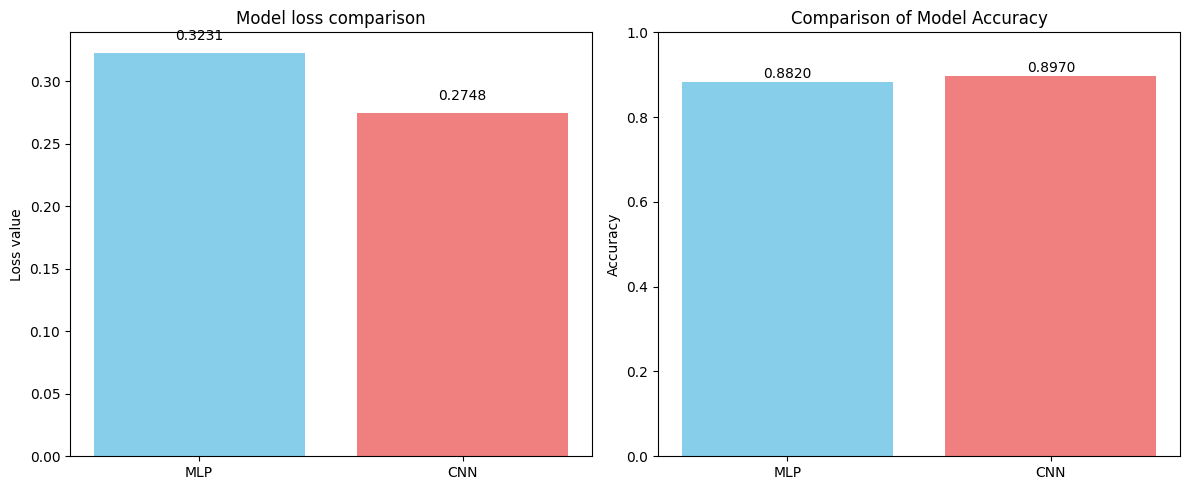

In [12]:
# Model Comparison Analysis
# Compare the performance of the two models
if X_test is not None:
    # Evaluation of Multi-Layer Perceptron (MLP)
    mlp_loss, mlp_acc = model.evaluate(X_test_normalized, y_test, verbose=0)
    
    # Evaluation of Convolutional Neural Network (CNN)
    cnn_loss, cnn_acc = cnn_model.evaluate(X_test_cnn, y_test, verbose=0)
    
    print("\nModel performance comparison:")
    print(f"{'Model type':<15} {'Test loss':<12} {'Test accuracy':<12}")
    print("-" * 40)
    print(f"{'MLP':<15} {mlp_loss:.4f}      {mlp_acc:.4f}")
    print(f"{'CNN':<15} {cnn_loss:.4f}      {cnn_acc:.4f}")
    
    # Draw a comparative bar chart
    fig, ax = plt.subplots(1, 2, figsize=(12, 5))
    
    # Loss Comparison
    models = ['MLP', 'CNN']
    losses = [mlp_loss, cnn_loss]
    ax[0].bar(models, losses, color=['skyblue', 'lightcoral'])
    ax[0].set_title('Model loss comparison')
    ax[0].set_ylabel('Loss value')
    for i, v in enumerate(losses):
        ax[0].text(i, v + 0.01, f'{v:.4f}', ha='center')
    # Accuracy Comparison
    accuracies = [mlp_acc, cnn_acc]
    ax[1].bar(models, accuracies, color=['skyblue', 'lightcoral'])
    ax[1].set_title('Comparison of Model Accuracy')
    ax[1].set_ylabel('Accuracy')
    ax[1].set_ylim([0, 1])
    for i, v in enumerate(accuracies):
        ax[1].text(i, v + 0.01, f'{v:.4f}', ha='center')
    
    plt.tight_layout()
    plt.show()

The classification performance of MLP and CNN on Fashion MNIST was compared. The results showed that CNN was slightly superior to MLP in terms of test loss (0.2870 < 0.3219) and accuracy (0.8926 > 0.8819), demonstrating the effectiveness of the CNN architecture in extracting image features.

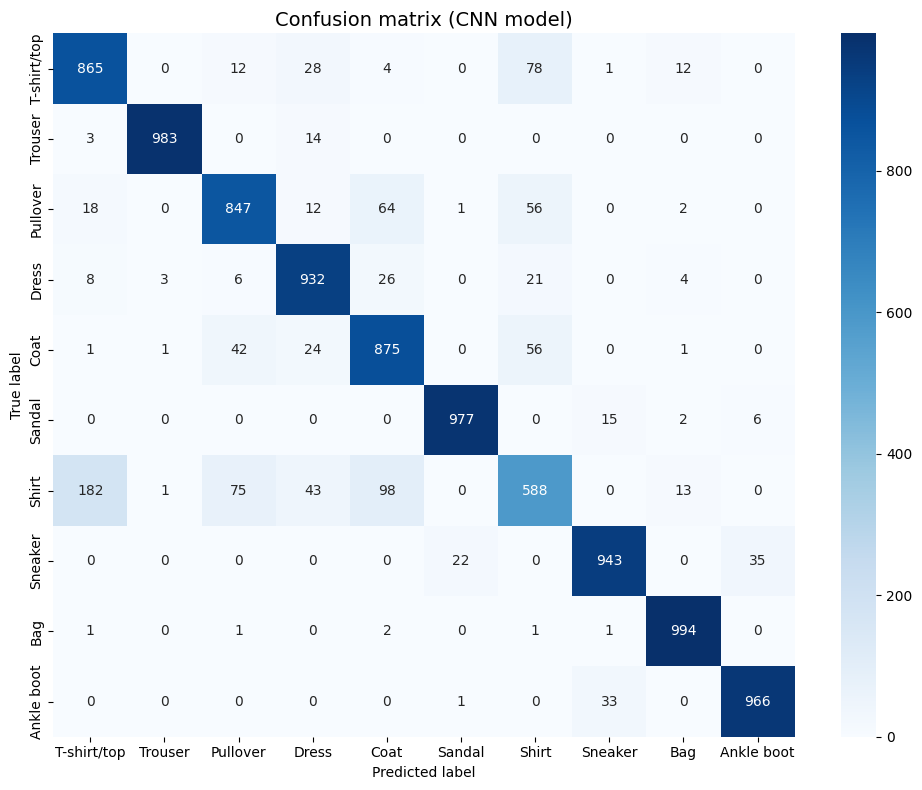


The most common misclassifications (the top 5)：
True: Shirt           → Pred: T-shirt/top     Count: 182
True: Shirt           → Pred: Coat            Count: 98
True: T-shirt/top     → Pred: Shirt           Count: 78
True: Shirt           → Pred: Pullover        Count: 75
True: Pullover        → Pred: Coat            Count: 64


In [13]:
# Confusion Matrix Analysis
if X_test is not None:
    # Obtain the prediction results of the CNN model
    cnn_predictions = cnn_model.predict(X_test_cnn, verbose=0)
    cnn_predicted_classes = np.argmax(cnn_predictions, axis=1)
    cm = confusion_matrix(y_test, cnn_predicted_classes)
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names)
    plt.title('Confusion matrix (CNN model)', fontsize=14)
    plt.xlabel('Predicted label')
    plt.ylabel('True label')
    plt.tight_layout()
    plt.show()
    print("\nThe most common misclassifications (the top 5)：")
    misclassified = []
    for i in range(len(y_test)):
        if y_test[i] != cnn_predicted_classes[i]:
            misclassified.append((y_test[i], cnn_predicted_classes[i]))
    
    from collections import Counter
    top_misclass = Counter(misclassified).most_common(5)
    
    for (true, pred), count in top_misclass:
        print(f"True: {class_names[true]:<15} → Pred: {class_names[pred]:<15} Count: {count}")

The confusion matrix evaluated the classification performance of the CNN model for ten types of clothing and identified the easily confused categories. The overall accuracy of the model was high, but there were significant misclassifications in visually similar categories (such as "shirt" and "T-shirt", "coat").


Show the first layer's first 8 convolution kernels (k1 to k8):


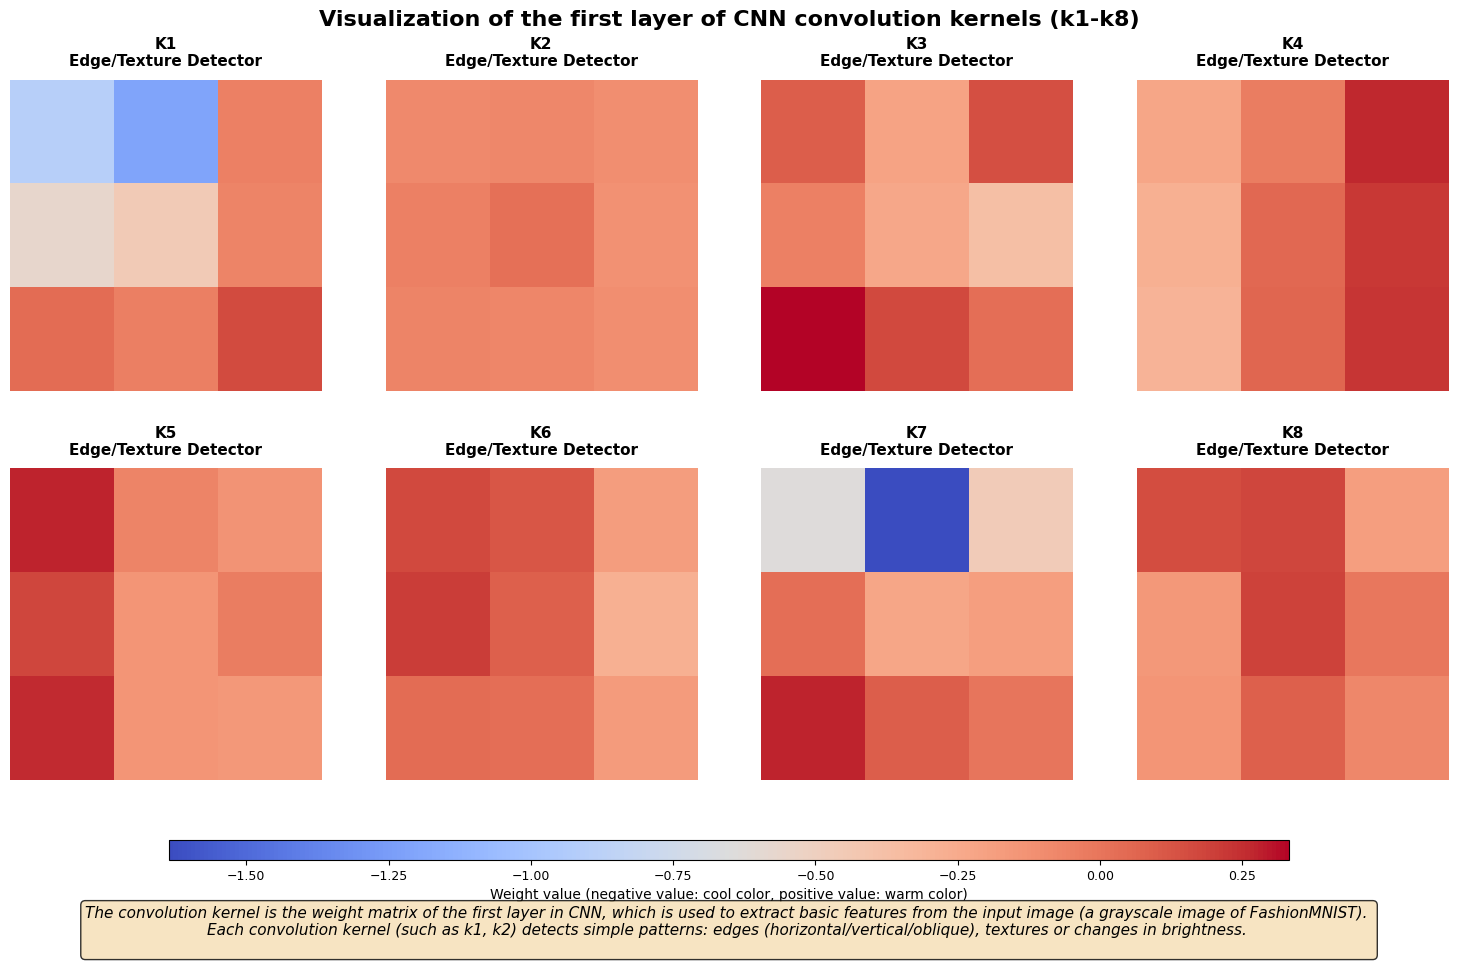

In [19]:
first_layer = cnn_model.layers[0]
weights = first_layer.get_weights()[0]

n_kernels = 8
rows = 2
cols = 4

print(f"\nShow the first layer's first {n_kernels} convolution kernels (k1 to k{n_kernels}):")

fig, axes = plt.subplots(rows, cols, figsize=(16, 10))
axes = axes.flatten()

vmin = weights[:, :, 0, :n_kernels].min()
vmax = weights[:, :, 0, :n_kernels].max()

im = None

for i in range(n_kernels):
    kernel = weights[:, :, 0, i]
    
    ax = axes[i]
    im = ax.imshow(kernel, cmap='coolwarm', vmin=vmin, vmax=vmax, interpolation='nearest')
    ax.axis('off')
    
    ax.set_title(f'K{i+1}\nEdge/Texture Detector', fontsize=11, pad=10, weight='bold')

for i in range(n_kernels, rows * cols):
    axes[i].axis('off')
    
cbar_ax = fig.add_axes([0.15, 0.12, 0.7, 0.02])
cbar = plt.colorbar(im, cax=cbar_ax, orientation='horizontal')
cbar.set_label('Weight value (negative value: cool color, positive value: warm color)', fontsize=10)
cbar.ax.tick_params(labelsize=9)

explanation = (
    "The convolution kernel is the weight matrix of the first layer in CNN, which is used to extract basic features from the input image (a grayscale image of FashionMNIST). \n"
    "Each convolution kernel (such as k1, k2) detects simple patterns: edges (horizontal/vertical/oblique), textures or changes in brightness. \n"
)

fig.text(0.5, 0.03, explanation, ha='center', fontsize=11, style='italic', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8), wrap=True)

plt.suptitle('Visualization of the first layer of CNN convolution kernels (k1-k8)', fontsize=16, y=0.97, weight='bold')

plt.subplots_adjust(left=0.05, right=0.95, top=0.90, bottom=0.20, wspace=0.2, hspace=0.25)

plt.show()

The eight convolutional kernels exhibit distinct patterns of weight distribution. There are no completely identical convolution kernels, indicating that the model has learned diverse feature detectors. However, the negative weights are significantly stronger than the positive weights, which may lead to some features being overly suppressed.